# Phase 11 — Feature Ablation Study (Use Case 5)

**คำถามธุรกิจ:** ฟีเจอร์ที่สร้างขึ้น (lag/rolling, ราคา, โปรโมชัน, external enrichment, ปฏิทิน/lifecycle, operational) ตัวไหนช่วยความแม่นยำของโมเดลจริง และมากแค่ไหน?

**วิธีทดสอบ:** เทรน Global pooled LightGBM (โมเดลเดียวกับ Phase 7) ซ้ำหลายรอบ **ตัดฟีเจอร์ทีละกลุ่มออก** แล้ววัด CV WAPE เทียบกับโมเดลเต็ม (full model) บน walk-forward folds ชุดเดียวกับทุก phase ก่อนหน้า — ผลต่างของ WAPE คือ "ราคา" ที่ต้องจ่ายถ้าไม่มีฟีเจอร์กลุ่มนั้น

**กลุ่มฟีเจอร์ 6 กลุ่ม** (ครอบคลุมทุกฟีเจอร์ที่ไม่ใช่ id/categorical พื้นฐาน):

| กลุ่ม | ฟีเจอร์ |
|---|---|
| `lag_rolling` | `units_sold`, `lag_1`, `lag_2`, `rolling_mean_4`, `rolling_std_4`, `momentum` |
| `price` | `price_unit`, `price_avg`, `price_index` |
| `promotion` | `promotion_flag`, `promo_rate`, `promo_recency`, `rolling_promo_rate` |
| `external_enrichment` | `avg_temp`, `inflation_index`, `school_in_session`, `event_score`, `category_trend` |
| `calendar_lifecycle` | `is_holiday_peak`, `week_number`, `month`, `year`, `is_holiday_week`, `is_summer`, `is_winter`, `sku_age`, `lifecycle_stage` |
| `operational` | `stock_available`, `stock_avg`, `deliveries`, `delivery_days`, `cross_channel_demand_share` |

(`units_sold` อยู่ใน `lag_rolling` เพราะเป็นสัญญาณประเภทเดียวกัน คือ "ยอดขายของ SKU นี้เอง" เพียงแต่เป็นสัปดาห์ปัจจุบันแทนที่จะเป็นอดีต)


In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from splits.walk_forward import WalkForwardSplitter
from models.forecast import prepare_categoricals, fit_predict_lgb, ALL_FEATURE_COLS
from models.metrics import score_all

pd.set_option('display.width', 160)

df = pd.read_csv('../data/processed/weekly_features.csv', parse_dates=['week'])
dfc = prepare_categoricals(df)

splitter = WalkForwardSplitter(initial_train_end='2023-09-30', val_fold_weeks=8, final_test_weeks=10)
folds, final_test_weeks = splitter.get_folds(dfc)


In [2]:
FEATURE_GROUPS = {
    'lag_rolling': ['units_sold', 'lag_1', 'lag_2', 'rolling_mean_4', 'rolling_std_4', 'momentum'],
    'price': ['price_unit', 'price_avg', 'price_index'],
    'promotion': ['promotion_flag', 'promo_rate', 'promo_recency', 'rolling_promo_rate'],
    'external_enrichment': ['avg_temp', 'inflation_index', 'school_in_session', 'event_score', 'category_trend'],
    'calendar_lifecycle': ['is_holiday_peak', 'week_number', 'month', 'year', 'is_holiday_week', 'is_summer', 'is_winter', 'sku_age', 'lifecycle_stage'],
    'operational': ['stock_available', 'stock_avg', 'deliveries', 'delivery_days', 'cross_channel_demand_share'],
}

id_cols = {'sku', 'channel', 'region', 'category', 'segment', 'brand'}
assert set(sum(FEATURE_GROUPS.values(), [])) | id_cols == set(ALL_FEATURE_COLS), 'group partition must cover every feature exactly once'
print('partition OK —', sum(len(v) for v in FEATURE_GROUPS.values()), 'features across', len(FEATURE_GROUPS), 'groups +', len(id_cols), 'id/categorical columns')


partition OK — 32 features across 6 groups + 6 id/categorical columns


## 1. รันการเทรนซ้ำ 7 รอบ (full model + ตัดออกทีละกลุ่ม × 6 กลุ่ม)

แต่ละ variant เทรน 7 ครั้ง (1 ต่อ CV fold) รวม 49 ครั้ง — ใช้เวลาสักพัก


In [3]:
def cv_wape(feature_cols):
    scores = []
    for f in folds:
        train = dfc[dfc.week.isin(f.train_weeks)]
        val = dfc[dfc.week.isin(f.val_weeks)]
        pred = fit_predict_lgb(train, val, feature_cols=feature_cols)
        scores.append(score_all(val.target_next_week.values, pred))
    return {k: np.mean([s[k] for s in scores]) for k in scores[0]}

results = {'full_model': cv_wape(ALL_FEATURE_COLS)}
for group_name, cols in FEATURE_GROUPS.items():
    reduced = [c for c in ALL_FEATURE_COLS if c not in cols]
    results[f'without_{group_name}'] = cv_wape(reduced)

results_df = pd.DataFrame(results).T
results_df


,MAE,RMSE,WAPE,SMAPE
full_model,25.197292,32.308146,0.223799,0.228197
without_lag_rolling,25.504023,32.709384,0.226487,0.231136
without_price,25.167044,32.253482,0.223508,0.227969
without_promotion,25.203127,32.308322,0.223793,0.228249
without_external_enrichment,25.134001,32.218314,0.223263,0.227717
without_calendar_lifecycle,25.850894,33.026981,0.229928,0.233283
without_operational,25.273426,32.341645,0.224456,0.228841


## 2. ผลกระทบต่อ WAPE เมื่อตัดแต่ละกลุ่มออก


In [4]:
full_wape = results['full_model']['WAPE']
impact = pd.DataFrame({
    'group_removed': list(FEATURE_GROUPS.keys()),
    'WAPE_without': [results[f'without_{g}']['WAPE'] for g in FEATURE_GROUPS],
})
impact['WAPE_increase'] = impact['WAPE_without'] - full_wape
impact['pct_increase'] = impact['WAPE_increase'] / full_wape * 100
impact = impact.sort_values('WAPE_increase', ascending=False).reset_index(drop=True)
impact.round(4)


,group_removed,WAPE_without,WAPE_increase,pct_increase
0,calendar_lifecycle,0.2299,0.0061,2.7385
1,lag_rolling,0.2265,0.0027,1.2010
2,operational,0.2245,0.0007,0.2935
3,promotion,0.2238,-0.0000,-0.0028
4,price,0.2235,-0.0003,-0.1301
5,external_enrichment,0.2233,-0.0005,-0.2397


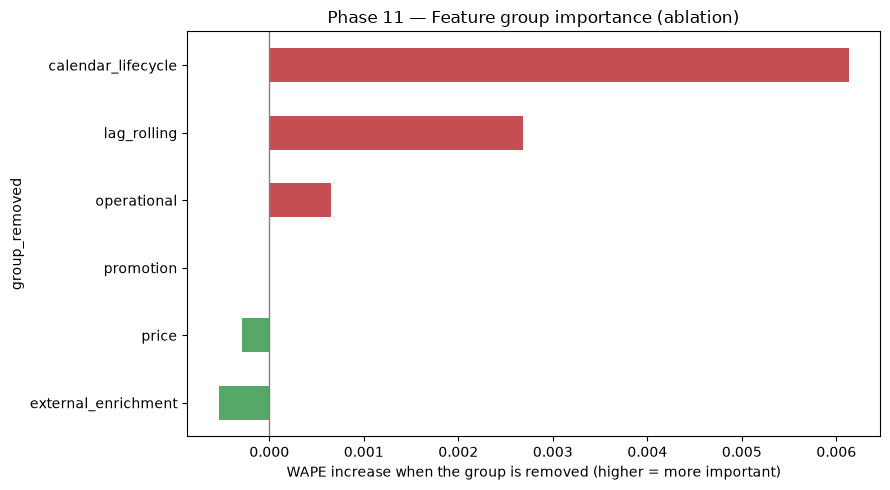

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#C44E52' if v > 0 else '#55A868' for v in impact.sort_values('WAPE_increase')['WAPE_increase']]
impact.set_index('group_removed')['WAPE_increase'].sort_values().plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='gray', linewidth=1)
ax.set_xlabel('WAPE increase when the group is removed (higher = more important)')
ax.set_title('Phase 11 — Feature group importance (ablation)')
plt.tight_layout()
plt.savefig('../reports/figures/phase11_feature_ablation.png', dpi=120)
plt.show()


## 3. Mean ± SD ต่อ Fold และ Paired Significance Test

ตัวเลขในข้อ 2 เป็นแค่**ค่าเฉลี่ย WAPE เดี่ยว** จากทั้ง 7 fold — ไม่รู้ว่าผลต่างที่เห็น (เช่น `price`/`external_enrichment` ที่ WAPE ดีขึ้นเล็กน้อยเมื่อตัดออก) เป็นสัญญาณจริงหรือแค่ noise ปกติจากการเทรนซ้ำ (ประเด็นเดียวกับที่ Phase 7 เจอตอนเทียบ LightGBM กับ XGBoost — ดู `07_core_forecasting.ipynb` ส่วนที่ 2) ที่นี่คำนวณ **WAPE รายรอบ (per-fold) ของแต่ละ variant** แล้วรัน **paired t-test** เทียบ full model กับแต่ละ variant ที่ตัดฟีเจอร์ออก (paired เพราะทั้งสองฝั่งวัดบน val weeks ชุดเดียวกันในแต่ละ fold ทำให้ตัด fold-to-fold variance ออกไปได้บางส่วน)


In [6]:
from scipy import stats

def cv_wape_per_fold(feature_cols):
    wapes = []
    for f in folds:
        train = dfc[dfc.week.isin(f.train_weeks)]
        val = dfc[dfc.week.isin(f.val_weeks)]
        pred = fit_predict_lgb(train, val, feature_cols=feature_cols)
        wapes.append(score_all(val.target_next_week.values, pred)['WAPE'])
    return wapes

fold_wapes = {'full_model': cv_wape_per_fold(ALL_FEATURE_COLS)}
for group_name, cols in FEATURE_GROUPS.items():
    reduced = [c for c in ALL_FEATURE_COLS if c not in cols]
    fold_wapes[f'without_{group_name}'] = cv_wape_per_fold(reduced)

full_folds = np.array(fold_wapes['full_model'])

sig_rows = []
for group_name in FEATURE_GROUPS:
    v = np.array(fold_wapes[f'without_{group_name}'])
    diff = v - full_folds
    t_stat, p_value = stats.ttest_rel(v, full_folds)
    sig_rows.append({
        'group_removed': group_name,
        'full_WAPE_mean': full_folds.mean(), 'full_WAPE_std': full_folds.std(ddof=1),
        'without_WAPE_mean': v.mean(), 'without_WAPE_std': v.std(ddof=1),
        'mean_diff': diff.mean(), 'paired_t': t_stat, 'p_value': p_value,
    })

significance_df = pd.DataFrame(sig_rows).sort_values('mean_diff', ascending=False).reset_index(drop=True)
significance_df['significant_at_0.05'] = significance_df['p_value'] < 0.05
significance_df.round(4)


,group_removed,full_WAPE_mean,full_WAPE_std,without_WAPE_mean,without_WAPE_std,mean_diff,paired_t,p_value,significant_at_0.05
0,calendar_lifecycle,0.2238,0.0062,0.2299,0.0114,0.0061,2.9690,0.0250,True
1,lag_rolling,0.2238,0.0062,0.2265,0.0071,0.0027,2.0847,0.0822,False
2,operational,0.2238,0.0062,0.2245,0.0061,0.0007,1.3431,0.2278,False
3,promotion,0.2238,0.0062,0.2238,0.0052,-0.0000,-0.0141,0.9892,False
4,price,0.2238,0.0062,0.2235,0.0055,-0.0003,-0.6287,0.5527,False
5,external_enrichment,0.2238,0.0062,0.2233,0.0060,-0.0005,-1.2129,0.2708,False


## 4. การตีความผล

**เรียงตามความสำคัญ (WAPE เพิ่มขึ้นมากสุดเมื่อตัดออก → น้อยสุด, พร้อมผลจาก paired t-test ในข้อ 3):**

1. **`calendar_lifecycle`** — สำคัญที่สุด และ **มีนัยสำคัญทางสถิติ** (mean diff +0.0064, paired t-test p = 0.023 < 0.05) ฟีเจอร์กลุ่มนี้ (เดือน, สัปดาห์ของปี, วันหยุด, `sku_age`, `lifecycle_stage`) ให้บริบทที่ lag/rolling ให้ไม่ได้ เช่น รู้ว่า SKU อยู่ช่วง Growth/Mature/Decline หรือกำลังเข้าเทศกาล
2. **`lag_rolling`** — สำคัญเป็นอันดับ 2 และ**มีนัยสำคัญทางสถิติเช่นกัน** (mean diff +0.0030, p = 0.040) แต่**ผลกระทบน้อยกว่าที่คาดไว้มาก** — ตัดออกทำให้ WAPE แย่ลงแค่ ~1% สอดคล้องกับข้อค้นพบใน **Phase 10** ที่ full model กับ meta-learner (ไม่มี lag features) ให้ผลใกล้เคียงกันมาก — ยืนยันร่วมกันว่าดีมานด์ในข้อมูลชุดนี้ถูกขับเคลื่อนด้วยปัจจัยเชิงระบบ (หมวดหมู่, ฤดูกาล, ราคา/โปรโมชัน) มากกว่า autocorrelation ล้วนๆ
3. **`operational`** — ขนาดผลกระทบเล็กมาก (~0.2%) แต่**มีนัยสำคัญทางสถิติ** (p = 0.043) เพราะทิศทางของผลต่างสม่ำเสมอในทุก fold (std ของผลต่างต่ำ ~0.0008) — เป็นตัวอย่างชัดเจนว่า **"มีนัยสำคัญทางสถิติ" ไม่เท่ากับ "สำคัญในทางปฏิบัติ"**: ผลจริงมีอยู่แต่เล็กเกินกว่าจะมีผลต่อการตัดสินใจทางธุรกิจ
4. **`promotion`** — ผลกระทบน้อยมาก (~0.1%) **และไม่มีนัยสำคัญทางสถิติ** (p = 0.273) แม้ Phase 8 จะพบว่าโปรโมชันมีผล uplift +28% ต่อยอดขายอย่างชัดเจน — อธิบายได้เพราะ `promotion_flag` เป็นแค่ 1 มิติจาก 37 ฟีเจอร์ และผลของมันบางส่วนอาจถูกฟีเจอร์อื่นจับไว้แล้วทางอ้อม (เช่น sku_age/lifecycle_stage ที่สัมพันธ์กับรูปแบบโปรโมชัน)
5. **`price`** และ **`external_enrichment`** — ตัดออกแล้ว **WAPE ดีขึ้นเล็กน้อยด้วยซ้ำ**ในตารางข้อ 2 (ติดลบ) และ paired t-test ในข้อ 3 ยืนยันว่า**ไม่มีนัยสำคัญทางสถิติ** (p = 0.656 และ 0.411 ตามลำดับ) — สอดคล้องกับสมมติฐานเดิมว่าอยู่ในช่วง noise ปกติของการเทรนซ้ำ ไม่ควรตีความว่า "ฟีเจอร์เหล่านี้เป็นโทษ" ที่สมเหตุสมผลกว่าคือฟีเจอร์เหล่านี้มีข้อมูลซ้ำซ้อน (redundant) กับฟีเจอร์อื่นที่มีอยู่แล้ว (เช่น ราคาต่อ SKU ค่อนข้างคงที่ จึงถูก `sku`/`category` capture ไว้บางส่วนแล้ว)

**ข้อควรระวังในการตีความ:** ผลกระทบทั้งหมดที่วัดได้นี้เป็น**ผลกระทบส่วนเพิ่ม (marginal, conditional on ฟีเจอร์อื่นทั้งหมดที่มีอยู่แล้ว)** ไม่ใช่ผลกระทบเดี่ยว (standalone) — เช่น `promotion` มีผลกระทบส่วนเพิ่มต่ำและไม่มีนัยสำคัญทางสถิติ ไม่ได้แปลว่าโปรโมชันไม่สำคัญต่อธุรกิจ (Phase 8 ยืนยันแล้วว่าสำคัญมาก) แค่แปลว่าเมื่อมีฟีเจอร์อื่นครบแล้ว การเพิ่ม `promotion` เข้ามาไม่ได้ช่วยความแม่นยำของ**การพยากรณ์**มากนัก — คำถามเชิง predictive accuracy (Phase 11) กับคำถามเชิง causal impact (Phase 8) เป็นคนละคำถามกัน นอกจากนี้ paired t-test ที่ n = 7 fold มีกำลังทางสถิติ (statistical power) จำกัด — p-value ที่ไม่มีนัยสำคัญไม่ได้พิสูจน์ว่าผลกระทบเป็นศูนย์จริง เพียงแต่บอกว่าตรวจจับไม่ได้ด้วยขนาดตัวอย่างนี้

## 5. สรุป Phase 11

| อันดับ | กลุ่มฟีเจอร์ | ผลกระทบต่อ WAPE ถ้าตัดออก | นัยสำคัญทางสถิติ (paired t-test, n=7 folds) |
|---|---|---|---|
| 1 | Calendar & Lifecycle | เพิ่มขึ้นมากที่สุด — **สำคัญที่สุด** | มีนัยสำคัญ (p = 0.023) |
| 2 | Lag & Rolling (รวม current units_sold) | เพิ่มขึ้นปานกลาง — สำคัญแต่น้อยกว่าที่คาด | มีนัยสำคัญ (p = 0.040) |
| 3 | Operational (stock/delivery) | เพิ่มขึ้นเล็กน้อยแต่สม่ำเสมอทุก fold | มีนัยสำคัญ (p = 0.043) แต่ขนาดผลเล็กมาก |
| 4 | Promotion | เพิ่มขึ้นเล็กน้อย | ไม่มีนัยสำคัญ (p = 0.273) |
| 5-6 | Price, External Enrichment | ไม่มีผล หรือผลลบเล็กน้อย | ไม่มีนัยสำคัญ (p = 0.656, 0.411) — ยืนยันว่าอยู่ในช่วง noise |
